# Embeddings and similarity scores
Computing the similarity score between cvs and job descriptions


## Set up the SDK

In [1]:
# !pip uninstall -qqy jupyterlab kfp  # Remove unused conflicting packages
!pip install -U -q "google-genai==1.7.0"

In [70]:
from google import genai
from google.genai import types

genai.__version__

'1.7.0'

### Set up your API key

To run the following cell, your API key must be stored it in a [Kaggle secret](https://www.kaggle.com/discussions/product-feedback/114053) named `GOOGLE_API_KEY`.

If you don't already have an API key, you can grab one from [AI Studio](https://aistudio.google.com/app/apikey). You can find [detailed instructions in the docs](https://ai.google.dev/gemini-api/docs/api-key).

To make the key available through Kaggle secrets, choose `Secrets` from the `Add-ons` menu and follow the instructions to add your key or enable it for this notebook.

In [71]:
GOOGLE_API_KEY = ''

### Explore available models

You will be using the [`embedContent`](https://ai.google.dev/api/embeddings#method:-models.embedcontent) API method to calculate batch embeddings in this guide. Find a model that supports it through the [`models.list`](https://ai.google.dev/api/models#method:-models.list) endpoint. You can also find more information about the embedding models on [the models page](https://ai.google.dev/gemini-api/docs/models/gemini#text-embedding).

In [72]:
client = genai.Client(api_key=GOOGLE_API_KEY)

for model in client.models.list():
  if 'embedContent' in model.supported_actions:
    print(model.name)

models/embedding-001
models/text-embedding-004
models/gemini-embedding-exp-03-07
models/gemini-embedding-exp


### Read data
Read the cv and job descriptions; covert from a word(.docx) file to text

In [73]:
from docx import Document
import glob

def extract_text_from_docx(file_path):
    """Extract text from a .docx file, including paragraphs and tables."""
    doc = Document(file_path)
    text = []
    
    # Extract paragraphs
    for paragraph in doc.paragraphs:
        text.append(paragraph.text)
    
    # Extract text from tables
    for table in doc.tables:
        for row in table.rows:
            for cell in row.cells:
                for paragraph in cell.paragraphs:
                    text.append(paragraph.text)
    
    return '\n'.join(text)
    
def read_folder(folder_path):
    folder_path = f'{folder_path}/*.docx'
    
    # Extract text from all .docx files in the folder
    text_array = []
    ids_array = []
    cur_id = 1
    for file_path in glob.glob(folder_path):
        text = extract_text_from_docx(file_path)
        text_array.append(text)
        ids_array.append(cur_id)
        cur_id += 1
        
    return ids_array, text_array 


In [74]:
cv_ids, cv_texts = read_folder('DataSet/cv')
job_ids, job_texts = read_folder('DataSet/job')

number_of_entries = 5

cv_ids = cv_ids[:number_of_entries]
cv_texts = cv_texts[:number_of_entries]
job_ids = job_ids[:number_of_entries]
job_texts = job_texts[:number_of_entries]

In [76]:
cv_embeddings = client.models.embed_content(
    model='models/text-embedding-004',
    contents=cv_texts,
    config=types.EmbedContentConfig(task_type='semantic_similarity'))
job_embeddings = client.models.embed_content(
    model='models/text-embedding-004',
    contents=job_texts,
    config=types.EmbedContentConfig(task_type='semantic_similarity'))


In [75]:
print(cv_texts[0], len(cv_texts))
print('-' * 100)
print(job_texts[0], len(job_texts))

Elena Andreea Vâlceanu
Technical Skills
Python, TensorFlow
JavaScript, ReactJS
AWS SageMaker, Docker
SQL, PostgreSQL
Figma, Adobe XD
Foreign Languages
- English: C1
- Spanish: B1
Education
- University Name: University Politehnica of Bucharest
- Program Duration: 4 years
- Master Degree Name: University Politehnica of Bucharest
- Program Duration: 2 years
Certifications
- AWS Certified Machine Learning – Specialty
- Docker Certified Associate
- TensorFlow Developer Certificate
Project Experience
1. Predictive Analytics Platform
   Developed a predictive analytics platform using Python and TensorFlow, aimed at providing real-time insights for retail businesses. Leveraged AWS SageMaker for model training and deployment, ensuring scalable and efficient processing of large datasets. Implemented Docker containers to streamline the development and deployment process, enhancing collaboration across teams. Technologies and tools used: Python, TensorFlow, AWS SageMaker, Docker.

2. Interactive 

A similarity score of two embedding vectors can be obtained by calculating their inner product. If $\mathbf{u}$ is the first embedding vector, and $\mathbf{v}$ the second, this is $\mathbf{u}^T \mathbf{v}$. As the API provides embedding vectors that are normalised to unit length, this is also the cosine similarity.

This score can be computed across all embeddings through the matrix self-multiplication: `df @ df.T`.

Note that the range from 0.0 (completely dissimilar) to 1.0 (completely similar) is depicted in the heatmap from light (0.0) to dark (1.0).

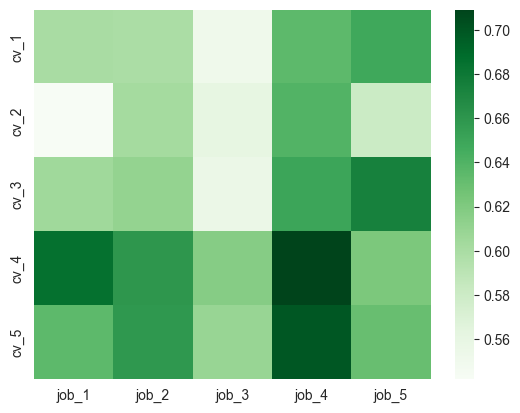

In [77]:
import pandas as pd
import seaborn as sns

# Set up the embeddings in a dataframe.
df_cv = pd.DataFrame([e.values for e in cv_embeddings.embeddings], index=['cv_' + str(cur_id) for cur_id in cv_ids])
df_job = pd.DataFrame([e.values for e in job_embeddings.embeddings], index=['job_' + str(cur_id) for cur_id in job_ids])

# Perform the similarity calculation
sim = df_cv @ df_job.T
mini = sim.min().min()
maxi = sim.max().max()

sns.heatmap(sim, vmin=mini, vmax=maxi, cmap='Greens')

## Further reading

* Explore [search re-ranking using embeddings](https://github.com/google-gemini/cookbook/blob/main/examples/Search_reranking_using_embeddings.ipynb) with the Wikipedia API
* Perform [anomaly detection using embeddings](https://github.com/google-gemini/cookbook/blob/main/examples/Anomaly_detection_with_embeddings.ipynb)

*- [Mark McD](https://linktr.ee/markmcd)*

In [79]:
for cv in cv_texts:
    print('-' * 100 + cv)

----------------------------------------------------------------------------------------------------Elena Andreea Vâlceanu
Technical Skills
Python, TensorFlow
JavaScript, ReactJS
AWS SageMaker, Docker
SQL, PostgreSQL
Figma, Adobe XD
Foreign Languages
- English: C1
- Spanish: B1
Education
- University Name: University Politehnica of Bucharest
- Program Duration: 4 years
- Master Degree Name: University Politehnica of Bucharest
- Program Duration: 2 years
Certifications
- AWS Certified Machine Learning – Specialty
- Docker Certified Associate
- TensorFlow Developer Certificate
Project Experience
1. Predictive Analytics Platform
   Developed a predictive analytics platform using Python and TensorFlow, aimed at providing real-time insights for retail businesses. Leveraged AWS SageMaker for model training and deployment, ensuring scalable and efficient processing of large datasets. Implemented Docker containers to streamline the development and deployment process, enhancing collaboration ac

In [80]:
print(job_texts[0])

Job Title:
Senior UI/UX Designer
Company Overview:
InnovateTech Solutions is a leading technology company dedicated to creating cutting-edge digital products that enhance user experiences across various platforms. Our team is passionate about innovation, creativity, and delivering exceptional solutions that meet the evolving needs of our clients. We pride ourselves on fostering a collaborative and inclusive work environment where every team member's ideas are valued and contribute to our success.
Key Responsibilities:
- Lead the design and development of user interfaces and experiences for web and mobile applications, ensuring a seamless and intuitive user journey.
- Collaborate with cross-functional teams, including product managers, developers, and other designers, to translate business requirements into innovative design solutions.
- Conduct user research and usability testing to gather insights and validate design concepts, iterating based on feedback to enhance user satisfaction.
